# Test de `river.py` -- pipeline complet + prévision réelle

Ce notebook teste, avec exécution réelle (cellules exécutées, résultats visibles) :

1. `preparer_donnees_legeres` corrigée (lots + pause, plus de perte silencieuse de points).
2. `executer_pipeline_gradient_boosting()` -- nouvelle fonction : enchaîne tout
   (bassins versants -> cache offline -> GA -> téléchargement complet ->
   Gradient Boosting entraîné), échelle réelle (grille 15x15, GA population
   20/50 générations, `predict_day=15`, 26 ans de données).
3. PCA et Keras corrigés : Keras tourne maintenant en espace BRUT (avec
   normalisation en entrée) au lieu d'être écrasé par une PCA à 19 composantes,
   et la PCA (utilisée uniquement par la régression linéaire) retient 99%
   d'énergie au lieu de 95%.
4. `predire_15_jours_reels()` -- nouvelle fonction : utilise la météo de
   PRÉVISION (pas l'archive) sur les points retenus pour prédire le débit réel
   des 15 prochains jours.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib
import pandas as pd

from river import River

STATION = "W231401001"  # La Bonne à Entraigues [Pont Battant]
PARAMS_HOURLY = ["snow_depth", "temperature_2m"]
PARAMS_DAILY = ["rain_sum"]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Pipeline complet jusqu'au Gradient Boosting

Réutilise `cache_eau_offline.csv` / `cache_meteo_offline.csv` pour le GA (aucun
appel réseau pour cette étape), puis télécharge les données complètes
(2000-11-01 -> 2026-02-01) uniquement sur les points retenus par le GA --
seule étape qui touche réellement Open-Meteo, et sur quelques points
seulement.


In [2]:
riviere = River(STATION, verbose=True)

modele_gb = riviere.executer_pipeline_gradient_boosting(
    params_hourly=PARAMS_HOURLY,
    params_daily=PARAMS_DAILY,
)
print("\nScore Gradient Boosting :", modele_gb["score"])
print("X_train2 :", riviere.X_train2.shape, "| X_test2 :", riviere.X_test2.shape)
print("Points retenus :", riviere.coords_finales)


✅ Station 'La Bonne à Entraigues [Pont Battant]' localisée (44.900346848, 5.94445407)
ℹ️ 🌍 Récupération des bassins versants depuis l'API Sandre...


✅ 4 zones hydrographiques trouvées !
ℹ️ 🎯 Génération des points strictement à l'intérieur des zones...
ℹ️    -> La Malsanne : 25 points validés.
ℹ️    -> La Bonne du canal de Beaumont inclus à la Malsanne : 25 points validés.
ℹ️    -> La Bonne de la Malsanne au Drac : 25 points validés.
ℹ️    -> Le Drac de la Souloise à la Bonne : 25 points validés.
✅ Carte sauvegardée sous 'bassins_versants.html'


⚠️ 4/100 points de la grille actuelle sont absents du cache chargé (ignorés par le GA).
✅ Cache offline chargé -> cache_eau_offline.csv / cache_meteo_offline.csv
ℹ️ 🕸️ Construction des matrices d'adjacence pour les zones...
ℹ️ 🧬 Lancement de l'Algorithme (Sélection : SUS | ADN Variable)...
ℹ️ 🚀 Premier appel : mise en cache et pré-calculs ultra-rapides...


✅ Pré-calcul terminé ! La sélection génétique va maintenant voler.



Évolution en cours:   0%|          | 0/50 [00:00<?, ?gén/s]

...


  0%|          | 0.00/103 [00:00<?, ?batch/s, loss=7.97]      


 89%|████████▉ | 92.0/103 [00:00<00:00, 916batch/s, loss=7.98]


100%|██████████| 150/150 [00:22<00:00,  6.04epoch/s, loss=8, val_loss=8.24, learning_rate=0.001]  


100%|██████████| 150/150 [00:22<00:00,  6.71epoch/s, loss=8, val_loss=8.24, learning_rate=0.001]

✅ Modèle hybride prêt pour 'gradient_boosting' !
✅ 🏆 Pipeline terminé : 'gradient_boosting' est prêt (riviere.modeles['gradient_boosting']).

Score Gradient Boosting : 0.7952319233092009
X_train2 : (7314, 1786) | X_test2 : (1738, 1786)
Points retenus : [(np.float64(44.9676), np.float64(5.9977)), (np.float64(44.9481), np.float64(5.9185)), (np.float64(44.7879), np.float64(5.8539)), (np.float64(44.922), np.float64(5.8173))]


## 2. PCA (99% d'énergie) + les 3 autres modèles (Ridge, Linéaire-PCA, Keras-brut)

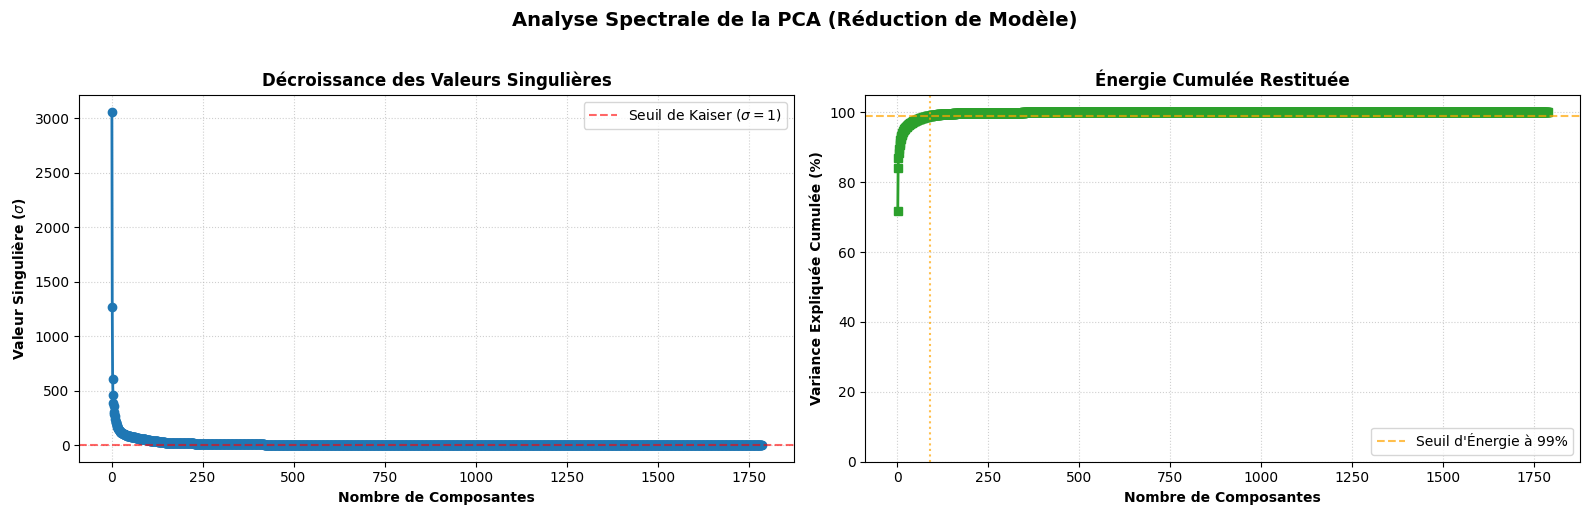

ℹ️ 📊 ANALYSE MACROSCOPIQUE :
ℹ️  - Nombre total de dimensions initiales : 1786
ℹ️  - Nombre de composantes pour atteindre 99% d'énergie : 90
ℹ️  - Énergie totale contenue dans les 3 premières composantes : 86.9 %


✅ CSV X (après PCA) sauvegardés.
Composantes PCA retenues (99% d'énergie) : 90


In [3]:
riviere.appliquer_pca(afficher_graphique=True)
print("Composantes PCA retenues (99% d'énergie) :", riviere.n_composantes_pca)


In [4]:
modeles = riviere.entrainer_tous_les_modeles(entrainer_incertitude_aussi=True)
list(modeles.keys())


ℹ️ Entraînement de la Régression Linéaire (PCA) en cours...
ℹ️ --- RÉSULTATS RÉGRESSION LINÉAIRE (PCA) ---
ℹ️ Prévision J0 (Aujourd'hui) : R² =  86.7 %
ℹ️ Prévision J+1             : R² =  83.3 %
ℹ️ Prévision J+2             : R² =  80.6 %
ℹ️ Prévision J+3             : R² =  78.3 %
ℹ️ Prévision J+4             : R² =  76.3 %
ℹ️ Prévision J+5             : R² =  74.7 %
ℹ️ Prévision J+6             : R² =  73.0 %
ℹ️ Prévision J+7             : R² =  71.1 %
ℹ️ Prévision J+8             : R² =  69.4 %
ℹ️ Prévision J+9             : R² =  68.0 %
ℹ️ Prévision J+10            : R² =  66.7 %
ℹ️ Prévision J+11            : R² =  65.5 %
ℹ️ Prévision J+12            : R² =  64.5 %
ℹ️ Prévision J+13            : R² =  63.8 %
ℹ️ Prévision J+14            : R² =  63.2 %
ℹ️ Prévision J+15            : R² =  62.5 %
ℹ️ Score R² pour cette configuration : 71.73 %
ℹ️ Entraînement de la Régression Ridge en cours...
ℹ️ --- RÉSULTATS RÉGRESSION RIDGE ---
ℹ️ Prévision J0 (Aujourd'hui) : R² =  92.2 %
ℹ️ Prév

ℹ️ --- RÉSULTATS GRADIENT BOOSTING ---
ℹ️ Prévision J0 (Aujourd'hui) : R² =  93.8 %
ℹ️ Prévision J+1             : R² =  89.7 %
ℹ️ Prévision J+2             : R² =  87.4 %
ℹ️ Prévision J+3             : R² =  85.1 %
ℹ️ Prévision J+4             : R² =  82.4 %
ℹ️ Prévision J+5             : R² =  80.8 %
ℹ️ Prévision J+6             : R² =  78.5 %
ℹ️ Prévision J+7             : R² =  78.1 %
ℹ️ Prévision J+8             : R² =  77.3 %
ℹ️ Prévision J+9             : R² =  76.1 %
ℹ️ Prévision J+10            : R² =  75.1 %
ℹ️ Prévision J+11            : R² =  74.4 %
ℹ️ Prévision J+12            : R² =  73.7 %
ℹ️ Prévision J+13            : R² =  73.6 %
ℹ️ Prévision J+14            : R² =  73.7 %
ℹ️ Prévision J+15            : R² =  72.8 %
ℹ️ Score R² pour cette configuration : 79.52 %
ℹ️ 🚀 Début de l'entraînement Keras (brut)...



0epoch [00:00, ?epoch/s]


0batch [00:00, ?batch/s]


  0%|          | 0/300 [00:00<?, ?epoch/s]

...


 96%|█████████▌| 99.0/103 [00:00<00:00, 970batch/s, loss=9.29]


100%|██████████| 150/150 [02:56<00:00,  7.69epoch/s, loss=9.29, val_loss=9.51, learning_rate=0.001]


100%|██████████| 150/150 [02:56<00:00,  1.17s/epoch, loss=9.29, val_loss=9.51, learning_rate=0.001]

✅ Modèle hybride prêt pour 'keras_brut' !
ℹ️ 
ℹ️ ==================================================
ℹ️ 📊 TABLEAU RÉCAPITULATIF DES SCORES R²
ℹ️ ==================================================
ℹ️   gradient_boosting      R² =  79.52 %
ℹ️   ridge_brut             R² =  75.19 %
ℹ️   keras_brut             R² =  72.64 %
ℹ️   lineaire_pca           R² =  71.73 %
ℹ️ ==================================================


['gradient_boosting', 'lineaire_pca', 'ridge_brut', 'keras_brut']

## 3. Audit de l'incertitude pour chaque modèle

In [5]:
for nom in riviere.modeles:
    print(f"--- {nom} ---")
    riviere.auditer_incertitude(nom)


--- gradient_boosting ---


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


...


 1/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step



 1/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step


ℹ️ 🔍 Audit probabiliste en cours...
ℹ️ 📊 RAPPORT DE QUALITÉ DE LA VARIANCE (Intervalle visé : 95%)
ℹ️ --------------------------------------------------
ℹ️ 🎯 Couverture Empirique : 89.3 %
ℹ️    ⚠️ Diagnostic : Modèle sur-confiant (Intervalles trop étroits, arrogant).
ℹ️ 📏 Largeur moyenne de l'IC 95% : 4280.7 L/s
ℹ️ 📉 Score NLL Global            : 9.294 (le plus bas possible est le meilleur)
ℹ️ --------------------------------------------------


## 4. Fan chart sur une date passée (tracer_prediction)

`construire_donnees_completes()` (appelé par le pipeline ci-dessus) sauvegarde
maintenant aussi les dates -- `tracer_prediction()` est donc utilisable
directement, contrairement au run précédent qui rechargeait un jeu de données
sans compagnon de dates.


Date choisie : 2023-05-25


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


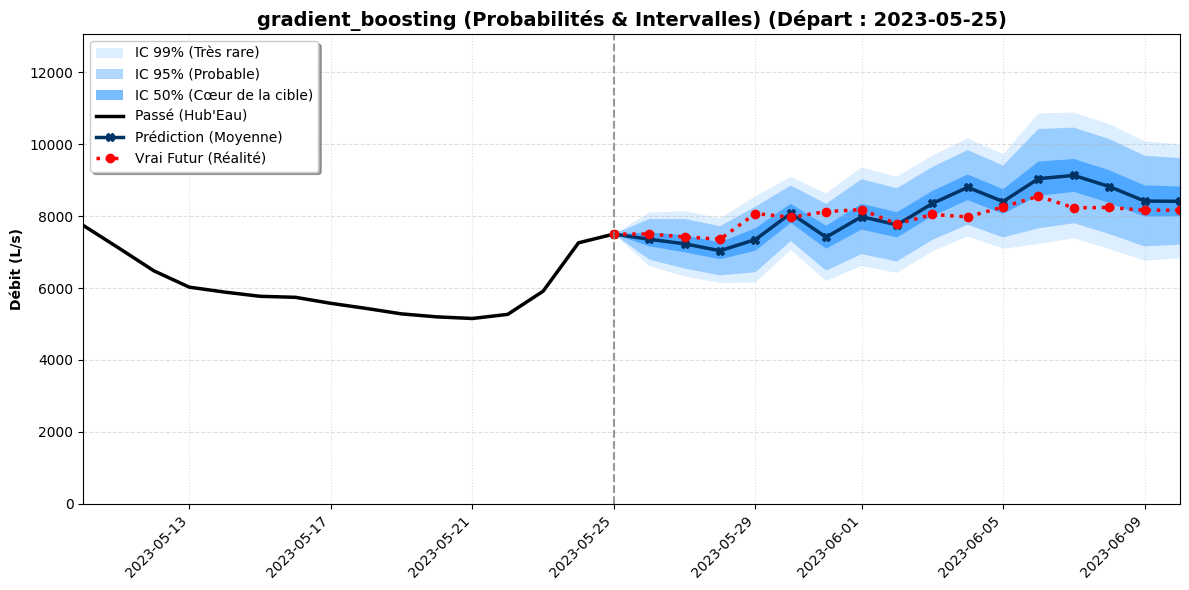

In [6]:
date_demo = riviere.test2['date'].iloc[len(riviere.test2)//2].strftime('%Y-%m-%d')
print("Date choisie :", date_demo)
riviere.tracer_prediction("gradient_boosting", date_demo, utiliser_hybride=True)


## 5. Prévision réelle des 15 prochains jours (météo FORECAST)

Utilise le débit récent (Hub'Eau) + la prévision météo Open-Meteo (pas
l'archive) sur les points retenus par le GA.


ℹ️ 💧 Téléchargement du débit récent Hub'Eau (2026-06-17 -> aujourd'hui)...


ℹ️ 📅 Dernier débit connu (J0) : 2026-07-11
ℹ️ 🌤 Téléchargement de la PRÉVISION météo (2026-06-17 -> 2026-07-27) sur 4 points...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


ℹ️ 🔮 PRÉVISION RÉELLE (gradient_boosting) à partir du 2026-07-11 :
ℹ️   2026-07-11 : 3482.2 L/s
ℹ️   2026-07-12 : 4844.1 L/s
ℹ️   2026-07-13 : 5098.1 L/s
ℹ️   2026-07-14 : 4666.7 L/s
ℹ️   2026-07-15 : 3814.4 L/s
ℹ️   2026-07-16 : 3260.3 L/s
ℹ️   2026-07-17 : 2878.4 L/s
ℹ️   2026-07-18 : 3503.1 L/s
ℹ️   2026-07-19 : 3275.2 L/s
ℹ️   2026-07-20 : 3831.1 L/s
ℹ️   2026-07-21 : 3503.2 L/s
ℹ️   2026-07-22 : 3077.1 L/s
ℹ️   2026-07-23 : 2402.3 L/s
ℹ️   2026-07-24 : 2667.4 L/s
ℹ️   2026-07-25 : 2985.8 L/s
ℹ️   2026-07-26 : 2416.1 L/s


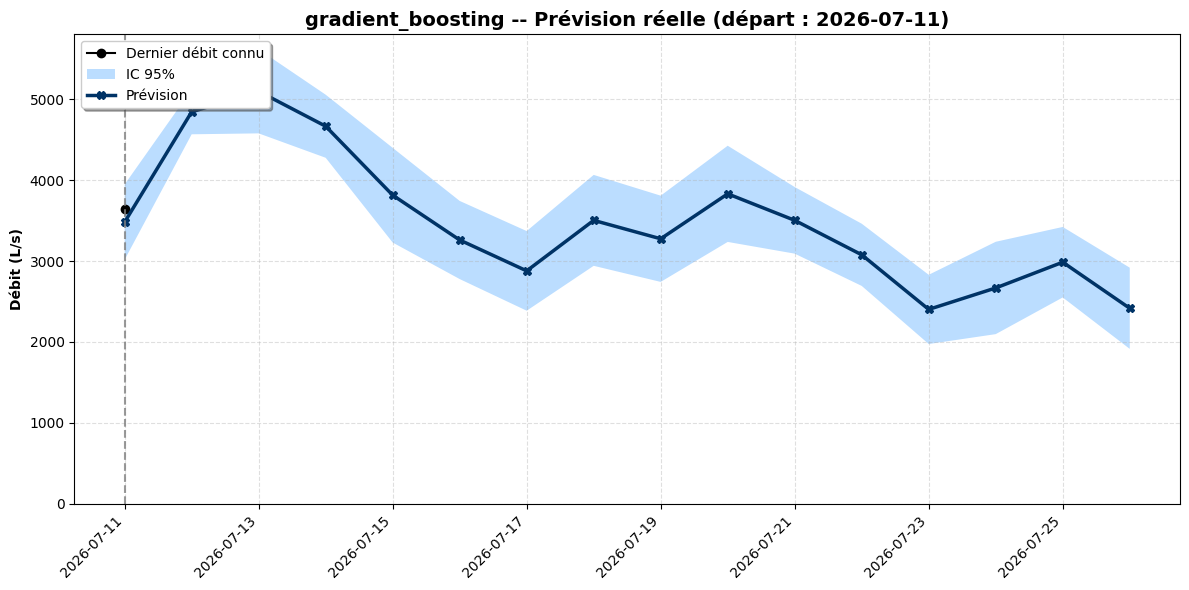

,date,debit_predit_L_s,ic_bas_95,ic_haut_95
0,2026-07-11,3482.168919,3017.052068,3947.285771
1,2026-07-12,4844.069252,4567.119270,5121.019233
2,2026-07-13,5098.073023,4578.494837,5617.651209
3,2026-07-14,4666.710671,4276.761178,5056.660165
4,2026-07-15,3814.428036,3229.195797,4399.660275
5,2026-07-16,3260.330882,2777.403300,3743.258464
6,2026-07-17,2878.372026,2386.112535,3370.631517
7,2026-07-18,3503.060952,2941.121499,4065.000405
8,2026-07-19,3275.231031,2742.075208,3808.386853
9,2026-07-20,3831.099740,3236.515329,4425.684152


In [7]:
prevision = riviere.predire_15_jours_reels(nom_modele="gradient_boosting",
                                            params_hourly=PARAMS_HOURLY,
                                            params_daily=PARAMS_DAILY)
prevision


## 6. Résumé final

In [8]:
riviere.afficher_resume()


RIVIÈRE : La Bonne à Entraigues [Pont Battant] (code W231401001)
Position : (44.900346848, 5.94445407)
Zones hydrographiques : 4 (100 points candidats)
Capteurs retenus par le GA : 4
Jeu d'entraînement : (7314, 1786) | Jeu de test : (1738, 1786)
Composantes PCA retenues : 90

Modèles entraînés :
  - gradient_boosting      R² =  79.52 % (+ incertitude)
  - ridge_brut             R² =  75.19 % (+ incertitude)
  - keras_brut             R² =  72.64 % (+ incertitude)
  - lineaire_pca           R² =  71.73 % (+ incertitude)
